# **2.** Datasets

In the first notebook, we have learnt the basics of data representations, and how data such as text, music and images, is stored as numbers in a computer. Later, we also explored how to extract useful information from these representations.

But, what is the natural next step for teaching a machine how to make decisions? 

Well, we need to have a data to work with! Think of it as examples the computer can look at to learn. We refer to this collection of data as a **dataset**.

Ideally, a **dataset** should meet the following criteria:

- Contain a **large number** of examples, and we will call each of them a **sample**, **observation** or **instance**;
- Be **representative** of the whole scope of possibilities we could encounter in the task we want to accomplish;
- Be available under a **permissive license** that allows for training machine learning models with non-commercial applications.

There are many available datasets that we can use for different applications, but we will select a relevant one for each type of data (text, music and images) to explore how to work with them.

 > Want to know what else is out there? You could look for available datasets on popular websites such as [`kaggle`](https://www.kaggle.com/datasets)!


## 1. Analysing Text

### 1.i. The Netflix Movies and TV Shows dataset

To continue our adventure analysing text, we'll take a look at the [Netflix Movies and TV Shows dataset](https://www.kaggle.com/datasets/shivamb/netflix-shows).

The dataset is released under a [`CC0: Public Domain` licence](https://creativecommons.org/publicdomain/zero/1.0/), which means we can use it without issues!


For each row of data, this database presents the following information:

* _show_id_: Unique ID for every Movie / TV Show
* _type_: Identifier - Movie or TV Show
* _title_
* _director_ (available for Movies)
* _cast_: Actors involved 
* _country_
* _date_added_: Date it was added on Netflix
* _release_year_: Actual Release year
* _rating_
* _duration_: Total Duration - in minutes or number of seasons
* _listed_in_: genres or categories
* _description_: text synopsis





> Can you think of interesting analysis to perform with this information?





For working with this dataset in this notebook, we can simply download it using the `kaggle` package.

In [2]:
!pip install kaggle
# Download the Netflix Movies and TV Shows dataset from Kaggle
!kaggle datasets download -d shivamb/netflix-shows


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


Since the dataset is in a zip file, we need to extract its content.

In [3]:
import zipfile
with zipfile.ZipFile("netflix-shows.zip", 'r') as zip_ref:
    zip_ref.extractall("netflix-shows")

The dataset is in the form of a `csv` file, that is _comma separated values_ that indicate data in the form of a table.
A useful library for working with `csv` files is `pandas`, which is usually referred to in code as `pd`.

In [4]:
import pandas as pd

netflix_titles = pd.read_csv("netflix-shows/netflix_titles.csv")

### 1.ii Exploring the Netflix Dataset

Let's visualise what data we have available. How many Movies and TV Shows do we have? What does the data look like?

In [5]:
# Check the structure and columns
print("Number of titles:", netflix_titles.shape[0])

print("\nColumn names:")
print(netflix_titles.columns.tolist())

print("\nFirst few rows:")
netflix_titles.head()

Number of titles: 8807

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First few rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


We have a lot to explore!  As a first approach, we'll only focus on the description and type information. 

We'll aim at answering this question: 

`Do Movies and TV Shows tend to have different descriptions?`

Later on, we'll use this analysis to explore the following task:

`If we have a description we haven't seen before, could we guess if it's a Movie or a TV Show with confidence?` 



Now, back to the data:

In [6]:
# keep only the type and description columns
netflix_titles_filtered = netflix_titles[['type', 'description']]

We can check the first row's description with the following code:

In [7]:
netflix_titles_filtered.loc[0, 'description']

'As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.'

And we can see its type like this:

In [8]:
netflix_titles_filtered.loc[0, 'type']

'Movie'

One of the first things we should check is how many samples we have for TV shows, and how many we have for movies:

Distribution of content types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage distribution:
type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64


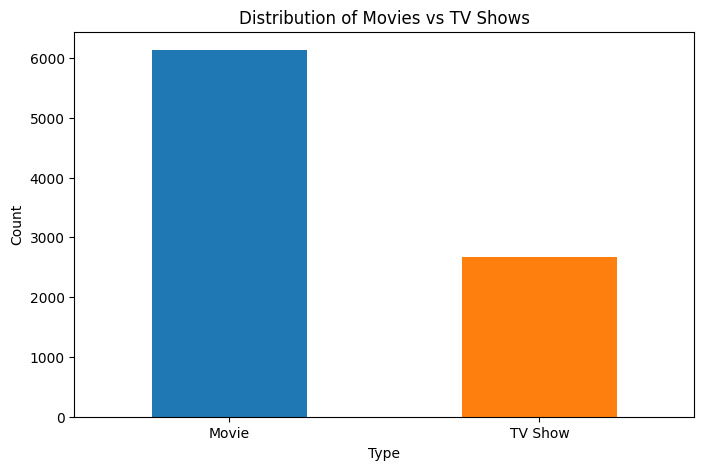

In [9]:
import matplotlib.pyplot as plt

# Check the distribution of Movies vs TV Shows
print("Distribution of content types:")
print(netflix_titles_filtered['type'].value_counts())
print("\nPercentage distribution:")
print(netflix_titles_filtered['type'].value_counts(normalize=True) * 100)

# Visualize the distribution
plt.figure(figsize=(8, 5))
netflix_titles_filtered['type'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

We have much more Movies than TV Shows in the database! We can say this database is _unbalanced_ in that sense: simply by having more examples, any algorithm we train will have more details about the behaviour of Movie descriptions. This can lead to problems when training if not handled properly, so we need to keep it in mind for our future work.

Going back to the data: If you were to read the description of one of the samples in the table, could you guess if it's a Movie or a TV Show? Can you think of possible words that would steer your decision one way or another?

Now, let's check what similar information could a machine get from the dataset!

### 1-iii. Text Analysis: Words and Bigrams in Descriptions 📊

Let's analyze the most common words and word-pairs (bigrams) in movies and TV show descriptions!

We have previously learnt how to perform this analysis for a single text. When we had just one text to analyse, our procedure was to simply use a counter to discover the frequency of each word or bigram. 

Now the situation is a bit different, since we have many different texts and two categories. How can we consider the information of many different texts to get an idea of how movies or TV shows descriptions tend to behave? 

While we could join all descriptions for movies and follow the procedure of the previous notebook, it would be helpful for our future tasks to preserve some sense of structure in the information: we need to be able to trace back how many times each word appeared in each individual text.

For this reason, we are going to use the `CountVectorizer` feature extractor from the `sklearn` library. This is a very useful object that:
1. Creates the vocabulary of all the words in all the descriptions (in the `fit` method)
2. Counts the times each word appears in each description (in the `transform` method)
3. Stores the counts of different words for each row (TV Show or Movie) in a table

Note that this approach allows us to track where each count of words came from!

Another advantage of using `CountVectorizer` is that it can automatically filter out common stop words (for example "the", "and" or "is") that don't add information about what the text is about. That is done adding the option `stop_words='english'` to the call. We can also focus on the 50 most common words by adding the `max_features=50` option.

Let's create a `CountVectorizer` and use to create our vocabulary!

In [107]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer for single words
word_vectorizer = CountVectorizer(
    # remove common English stop words e.g., "the", "and", "is", they don't add much information
    stop_words='english',
    # only keep the most common 50 words
    max_features=50
)

# fit the vectorizer to the descriptions in the dataset: build vocabulary!
word_vectorizer.fit(netflix_titles_filtered['description'])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


We can use `CountVectorizer`'s `transform` method to analyse the data, that is, count how many times each word in the vocabulary appears in each description.

In [108]:
# Use CountVectorizer to analyse all descriptions
word_counts = word_vectorizer.transform(netflix_titles_filtered['description'])

The table built by `CountVectorizer` has:
* as many rows as descriptions we are analysing (8807 in this case).
* one column per each top common words (50 in this case). 

The stored information is, then, for each desciption and each top word, how many times did that word appear in that description.

In [109]:
print(word_counts.shape)

(8807, 50)


Let's visualize what this table actually looks like! We'll show the first 10 descriptions to see how words are counted.

In [110]:
# Format a table of word counts for each description
# Make sure we're using the 2D sparse matrix from the vectorizer transform
word_counts_matrix = word_vectorizer.transform(netflix_titles_filtered['description'])

# Show only first 20 descriptions and 20 first top words for brevity
word_counts_table = pd.DataFrame(
    word_counts_matrix[:20, :20].toarray(),
    columns=word_vectorizer.get_feature_names_out()[:20]
)

In [111]:
word_counts_table

,best,boy,city,comedy,crime,daughter,death,documentary,family,father,finds,friend,friends,gets,girl,group,help,high,home,life
0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


Notice that:
- Each **row** represents one description (Movie or TV Show)
- Each **column** represents a word from the vocabulary of 50 most common words
- Each **number** shows how many times that word appears in that description
- Most cells are **0** because most words don't appear in most descriptions!

Given this table, we can count how many times each top word appeared along all descriptions. For this, we need to sum all the information in each column (counts for a given word) for all rows (different descriptions). We can do that with the `sum` method, choosing `axis=0` to indicate we are summing along columns.

In [112]:
word_freq = dict(zip(word_vectorizer.get_feature_names_out(), word_counts.sum(axis=0).A1))

If we restrict this to the 20 most frequent words, we can visualize this information in a histogram as we did in the previous notebook:

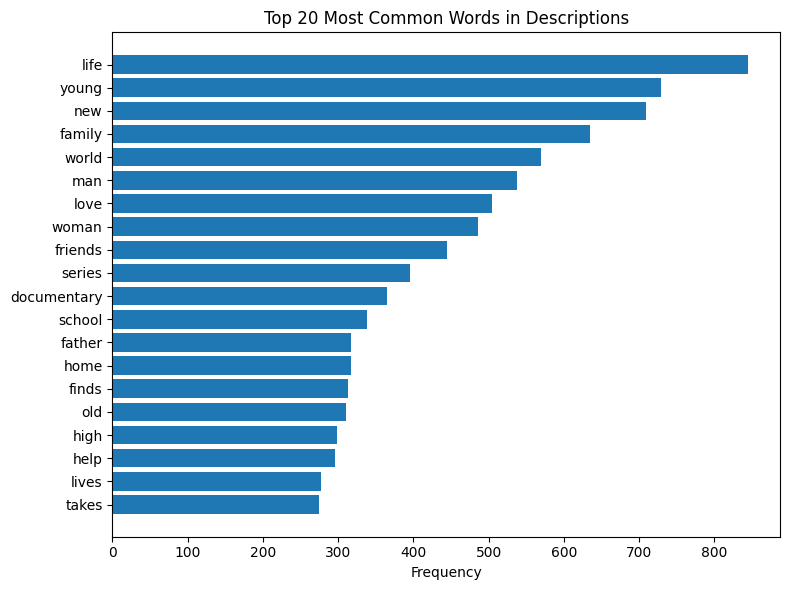

In [113]:
def get_frequency(word_freq_pair):
    word, frequency = word_freq_pair
    return frequency

# rearrange top words in order of frequency and get only top 20
top_words = sorted(word_freq.items(), key=get_frequency, reverse=True)[:20]
words = [word for word, freq in top_words]
freqs = [freq for word, freq in top_words]

# Visualize single histogram
plt.figure(figsize=(8, 6))
plt.barh(words, freqs, color='#1f77b4')
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words in Descriptions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [114]:
# Show only first 10 descriptions and the 20 most popular words
# First, find the indices of the 20 most frequent words
word_totals = word_counts.sum(axis=0).A1  # Total count for each word across all descriptions
top_20_indices = word_totals.argsort()[-20:][::-1]  # Get indices of top 20, in descending order

# Create DataFrame with first 10 descriptions and top 20 most popular words
word_counts_df = pd.DataFrame(
    word_counts.toarray()[:10, top_20_indices],  # First 10 descriptions, top 20 most popular words
    columns=word_vectorizer.get_feature_names_out()[top_20_indices]
)

print("Word counts for first 10 descriptions (showing 20 most popular words):")
word_counts_df

Word counts for first 10 descriptions (showing 20 most popular words):


,life,young,new,family,world,man,love,woman,friends,series,documentary,school,home,father,finds,old,high,help,lives,takes
0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


But, what about the behaviour for Movies separately from TV Shows?

In [115]:
# get a true/false mask for movies and TV shows
movie_mask = netflix_titles_filtered['type'] == 'Movie'
tv_mask = netflix_titles_filtered['type'] == 'TV Show'

# Convert pandas Series to numpy arrays for sparse matrix indexing
movie_word_counts = word_counts[movie_mask.values]
tv_word_counts = word_counts[tv_mask.values]

In [116]:
# Get word frequencies for movies and TV shows
movie_word_freq = dict(zip(word_vectorizer.get_feature_names_out(), movie_word_counts.sum(axis=0).A1))
tv_word_freq = dict(zip(word_vectorizer.get_feature_names_out(), tv_word_counts.sum(axis=0).A1))

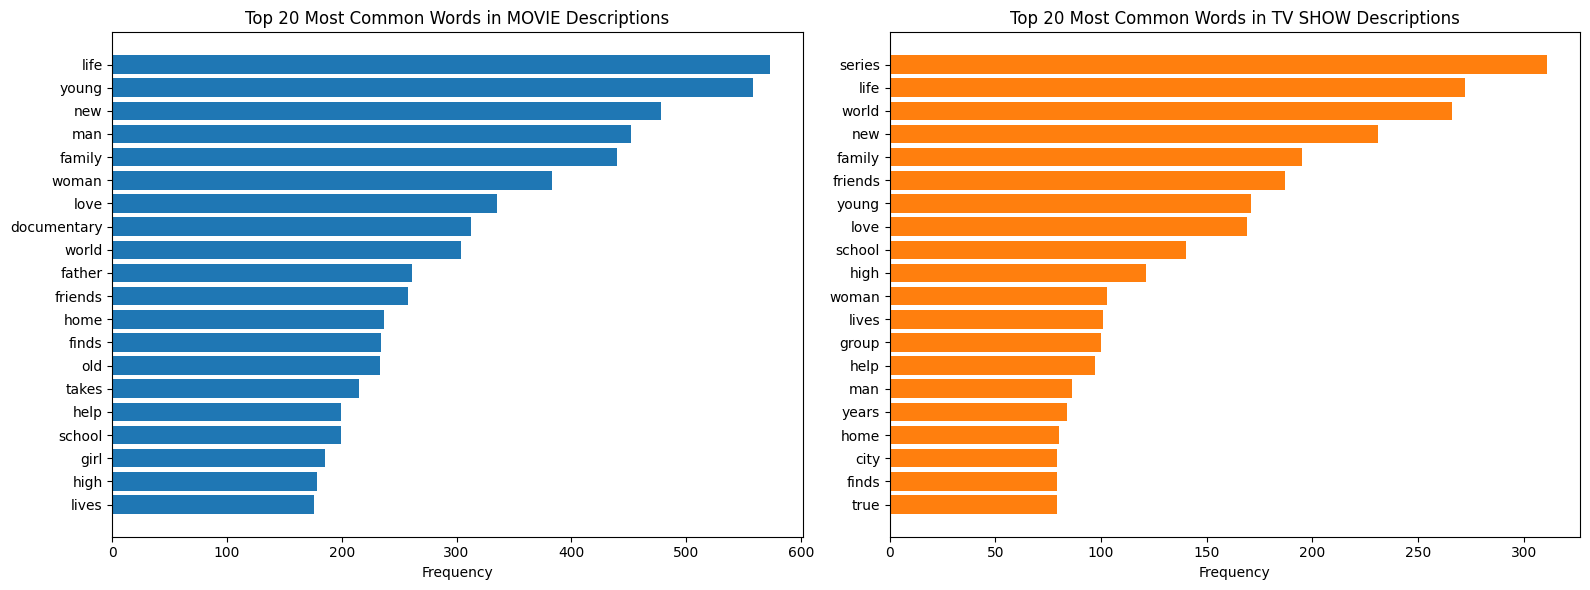

In [117]:
def get_frequency(word_freq_pair):
    word, frequency = word_freq_pair
    return frequency

# rearrange movie top words in order of frequency
top_movie_words = sorted(movie_word_freq.items(), key=get_frequency, reverse=True)[:20]
movie_words = [word for word, freq in top_movie_words]
movie_freqs = [freq for word, freq in top_movie_words]
# rearrange TV show top words in order of frequency
top_tv_words = sorted(tv_word_freq.items(), key=get_frequency, reverse=True)[:20]
tv_words = [word for word, freq in top_tv_words]
tv_freqs = [freq for word, freq in top_tv_words]

# Visualize
# generate a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movie words in the left subplot
ax1.barh(movie_words, movie_freqs, color='#1f77b4')
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Most Common Words in MOVIE Descriptions')
ax1.invert_yaxis()

# TV Show words in the right subplot
ax2.barh(tv_words, tv_freqs, color='#ff7f0e')
ax2.set_xlabel('Frequency')
ax2.set_title('Top 20 Most Common Words in TV SHOW Descriptions')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

We can see that the most used word for describing TV Shows is `series`, which makes a lot of sense!

What happens when we take a look at bigrams?

This visualization shows how Movies and TV Shows are distributed based on their word usage patterns. The two principal components capture the most important variations in word usage across all descriptions.

Can you see any separation between the two categories? Do they form distinct clusters or do they overlap? This will give us insight into whether word counts alone can help distinguish Movies from TV Shows.

### 1-iv. Most Common Bigrams (Word Pairs)

For bigrams we can take a very similar procedure. We need to change the settings on `CountVectorizer` so that it count ocurrences of two consecutive words. We do this by adding the `ngram_range=(2, 2)` option in the call.

In [118]:
# Create a CountVectorizer for bigrams (word pairs)
bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),  # Bigrams only (pairs of consecutive words)
    max_features=50
)

# Get bigram counts
bigram_counts = bigram_vectorizer.fit_transform(netflix_titles_filtered['description'])

How many bigrams do we have?

In [119]:
print(bigram_counts.shape)

(8807, 50)


Let's separate the information of TV Shows and Movies:

In [120]:
# Convert pandas Series to numpy arrays for sparse matrix indexing
movie_bigrams_counts = bigram_counts[movie_mask.values]
tv_bigrams_counts = bigram_counts[tv_mask.values]

# Get bigram frequencies for movies and TV shows
movie_bigrams_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), movie_bigrams_counts.sum(axis=0).A1))
tv_bigrams_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), tv_bigrams_counts.sum(axis=0).A1))

Let's take a look at the histograms!

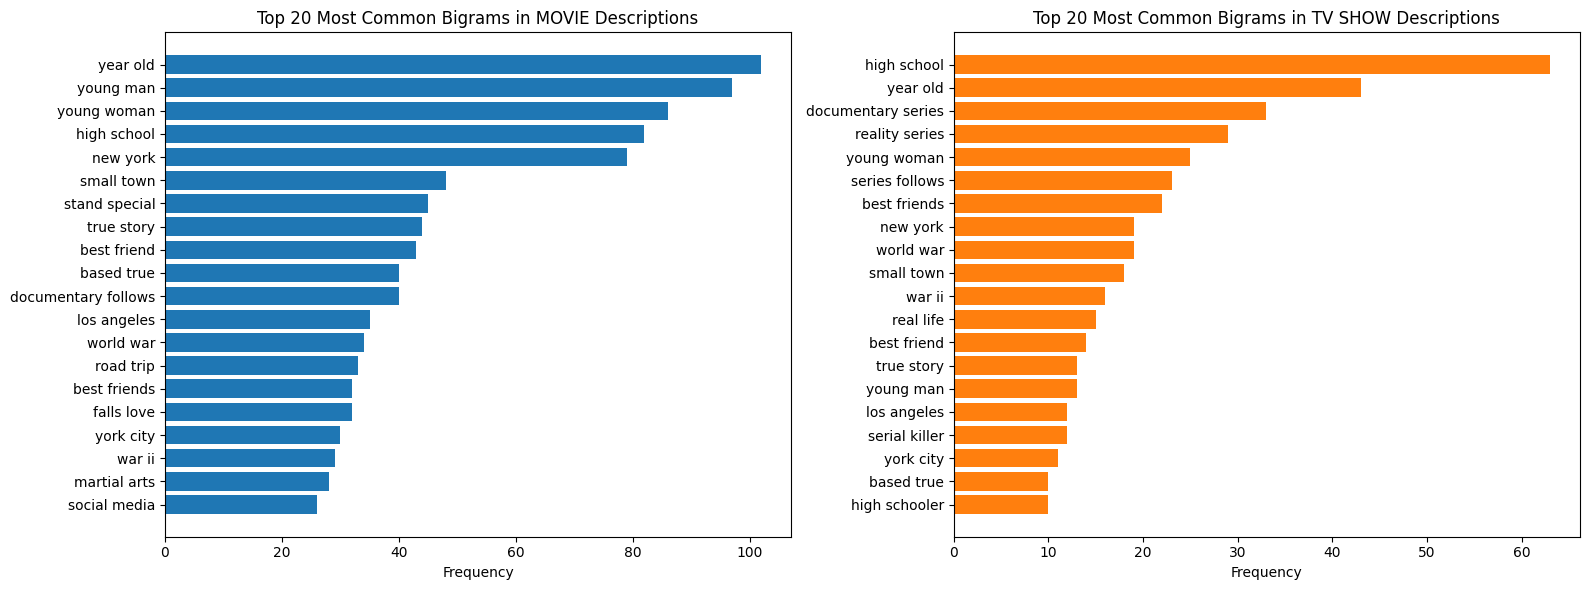

In [121]:
# rearrange movie top bigrams in order of frequency
top_movie_bigrams = sorted(movie_bigrams_freq.items(), key=get_frequency, reverse=True)[:20]
movie_bigrams = [bigram for bigram, freq in top_movie_bigrams]
movie_bigram_freqs = [freq for bigram, freq in top_movie_bigrams]
# rearrange TV show top bigrams in order of frequency
top_tv_bigrams = sorted(tv_bigrams_freq.items(), key=get_frequency, reverse=True)[:20]
tv_bigrams = [bigram for bigram, freq in top_tv_bigrams]
tv_bigram_freqs = [freq for bigram, freq in top_tv_bigrams]

# Visualize bigrams
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movie bigrams in the left subplot
ax1.barh(movie_bigrams, movie_bigram_freqs, color='#1f77b4')
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Most Common Bigrams in MOVIE Descriptions')
ax1.invert_yaxis()

# TV Show bigrams in the right subplot
ax2.barh(tv_bigrams, tv_bigram_freqs, color='#ff7f0e')
ax2.set_xlabel('Frequency')
ax2.set_title('Top 20 Most Common Bigrams in TV SHOW Descriptions')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


Some bigrams are very common in both cases, such as `year old` and `high school`. We can see that `documentary` appears in both, but when it's for TV shows it appears as `documentary series`.

 What other trends can you spot?

In order to train a machine learning model with this data, we need to join word counts and bigram counts into a single stack of features.

In [122]:
from scipy.sparse import hstack

# Reuse the already computed word and bigram counts
combined_counts = hstack([word_counts, bigram_counts])

print(f"Combined shape: {combined_counts.shape}")

Combined shape: (8807, 100)


In [123]:
# Filter out rows with all zeros (no features)
non_zero_mask = combined_counts.toarray().sum(axis=1) > 0
combined_counts_filtered = combined_counts[non_zero_mask]
netflix_titles_filtered_cleaned = netflix_titles_filtered[non_zero_mask]
labels_filtered = netflix_titles_filtered['type'][non_zero_mask]
movie_mask_filtered = labels_filtered == 'Movie'
tv_mask_filtered = labels_filtered == 'TV Show'

print(f"Original shape: {combined_counts.shape}")
print(f"Filtered shape: {combined_counts_filtered.shape}")
print(f"Rows removed: {combined_counts.shape[0] - combined_counts_filtered.shape[0]}")

Original shape: (8807, 100)
Filtered shape: (7138, 100)
Rows removed: 1669


In [129]:
from sklearn.decomposition import PCA

# Perform PCA to reduce to 2 components for visualization
pca = PCA(n_components=50)
fitted_pca = pca.fit_transform(combined_counts_filtered.toarray())

print(f"Original shape: {combined_counts_filtered.shape}")
print(f"After PCA: {fitted_pca.shape}") 
print(f"\nVariance explained by each component: {pca.explained_variance_ratio_}") 
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Original shape: (7138, 100)
After PCA: (7138, 50)

Variance explained by each component: [0.05015199 0.04773375 0.04311159 0.03674286 0.03564279 0.03329828
 0.03219073 0.03044807 0.02922871 0.02685677 0.02616732 0.02325485
 0.02110474 0.01906237 0.01870538 0.01836519 0.01785393 0.0174856
 0.01704351 0.01595019 0.01570702 0.01541197 0.0152583  0.01499479
 0.01423763 0.01406218 0.01394935 0.01357928 0.01344727 0.01333298
 0.01236782 0.01236145 0.01206138 0.01174156 0.01151165 0.01139723
 0.01110074 0.01084336 0.01063423 0.01048009 0.01037727 0.01026235
 0.01001451 0.00989543 0.00982531 0.00976701 0.00927238 0.00812457
 0.0077929  0.00729652]
Total variance explained: 91.15%


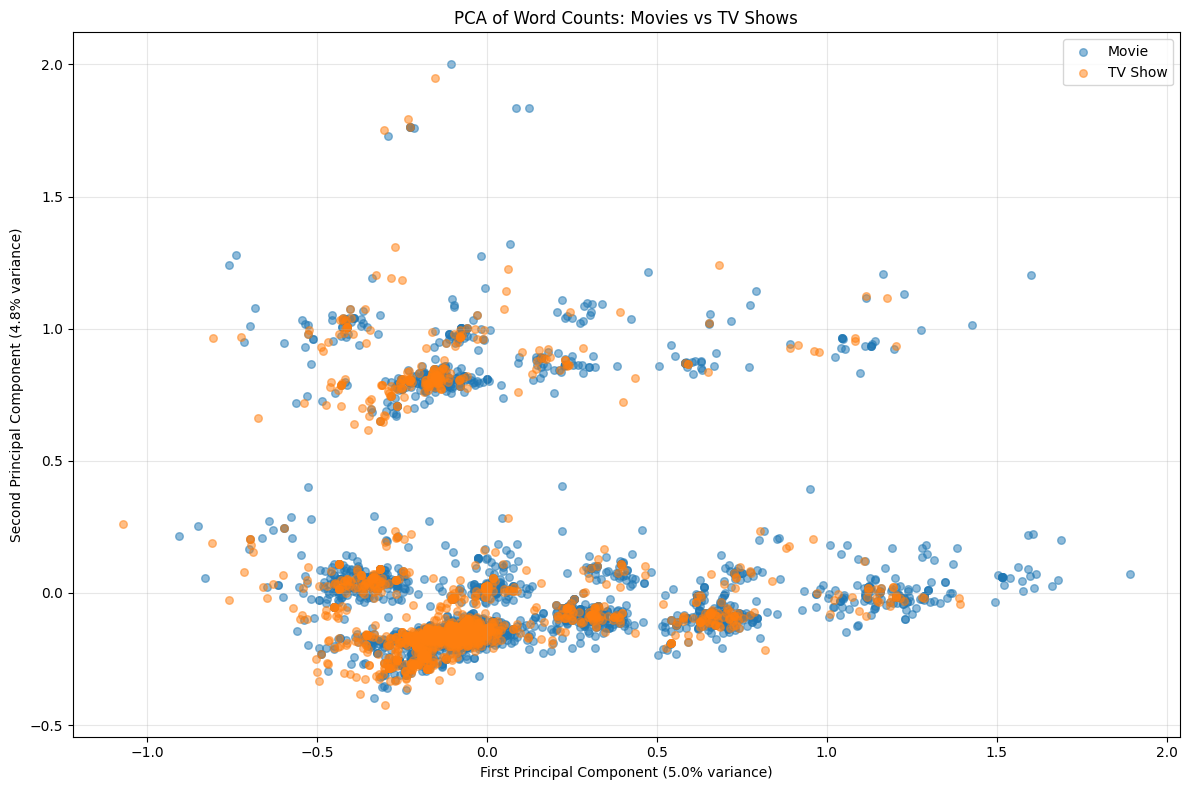

In [125]:
# Create a scatter plot of the PCA results
plt.figure(figsize=(12, 8))

# Separate the PCA results by type
movie_word_pca = fitted_pca[movie_mask_filtered.values]
tv_word_pca = fitted_pca[tv_mask_filtered.values]

# Plot Movies in blue and TV Shows in orange
plt.scatter(movie_word_pca[:, 0], movie_word_pca[:, 1], alpha=0.5, c='#1f77b4', label='Movie', s=30)
plt.scatter(tv_word_pca[:, 0], tv_word_pca[:, 1], alpha=0.5, c='#ff7f0e', label='TV Show', s=30)

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Word Counts: Movies vs TV Shows')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 features contributing to PC1:
young          0.732401
man            0.381581
woman          0.310772
young man      0.165605
young woman    0.153232
high          -0.096695
friends       -0.099694
world         -0.114061
school        -0.114475
new           -0.261124
Name: PC1, dtype: float64

Top 10 features contributing to PC2:
life       0.947125
new        0.188943
love       0.152315
woman      0.073147
young      0.053308
man        0.047958
lives     -0.037122
friends   -0.043357
help      -0.045039
world     -0.109846
Name: PC2, dtype: float64


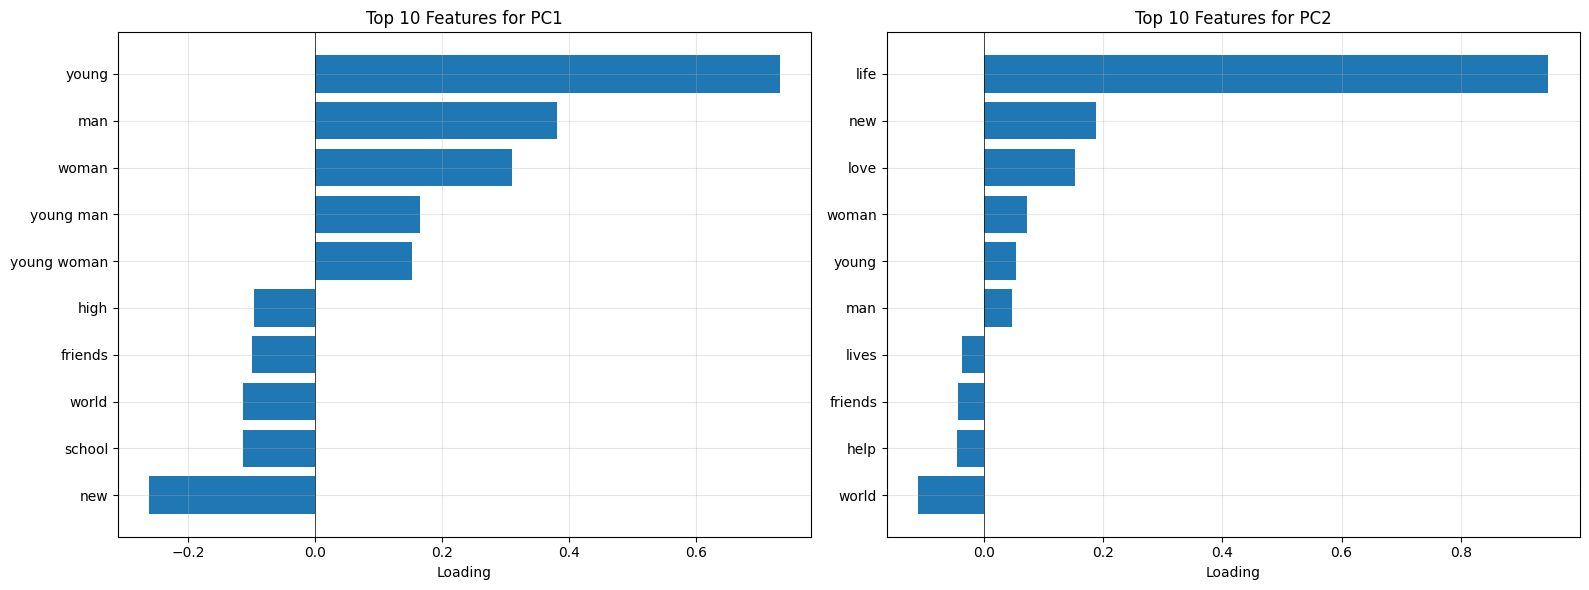

In [29]:
# Get all feature names (words + bigrams)
text_feature_names = list(word_vectorizer.get_feature_names_out()) + list(bigram_vectorizer.get_feature_names_out())

# Display the loadings for top contributing features
loadings_text = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=text_feature_names
)

# Get top 10 features for each PC by absolute loading value
top_pc1 = loadings_text['PC1'].abs().nlargest(10)
top_pc2 = loadings_text['PC2'].abs().nlargest(10)

print("Top 10 features contributing to PC1:")
print(loadings_text.loc[top_pc1.index, 'PC1'].sort_values(ascending=False))
print("\nTop 10 features contributing to PC2:")
print(loadings_text.loc[top_pc2.index, 'PC2'].sort_values(ascending=False))

# Visualize the top loadings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 top features
pc1_data = loadings_text.loc[top_pc1.index, 'PC1'].sort_values()
axes[0].barh(range(len(pc1_data)), pc1_data.values)
axes[0].set_yticks(range(len(pc1_data)))
axes[0].set_yticklabels(pc1_data.index)
axes[0].set_xlabel('Loading')
axes[0].set_title('Top 10 Features for PC1')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# PC2 top features
pc2_data = loadings_text.loc[top_pc2.index, 'PC2'].sort_values()
axes[1].barh(range(len(pc2_data)), pc2_data.values)
axes[1].set_yticks(range(len(pc2_data)))
axes[1].set_yticklabels(pc2_data.index)
axes[1].set_xlabel('Loading')
axes[1].set_title('Top 10 Features for PC2')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 10 Most Distinctive MOVIE Features:
    feature    ratio
        man 1.049682
documentary 1.038315
      young 1.031513
      woman 1.028575
     father 1.026235
        son 1.018512
    special 1.017916
     friend 1.017238
      takes 1.015375
     mother 1.014966


Top 10 Most Distinctive TV SHOW Features:
           feature    ratio
            series 0.890046
             world 0.945782
           friends 0.968833
            school 0.977301
              high 0.981367
documentary series 0.985670
    reality series 0.986860
       high school 0.987955
             group 0.988100
        mysterious 0.988394


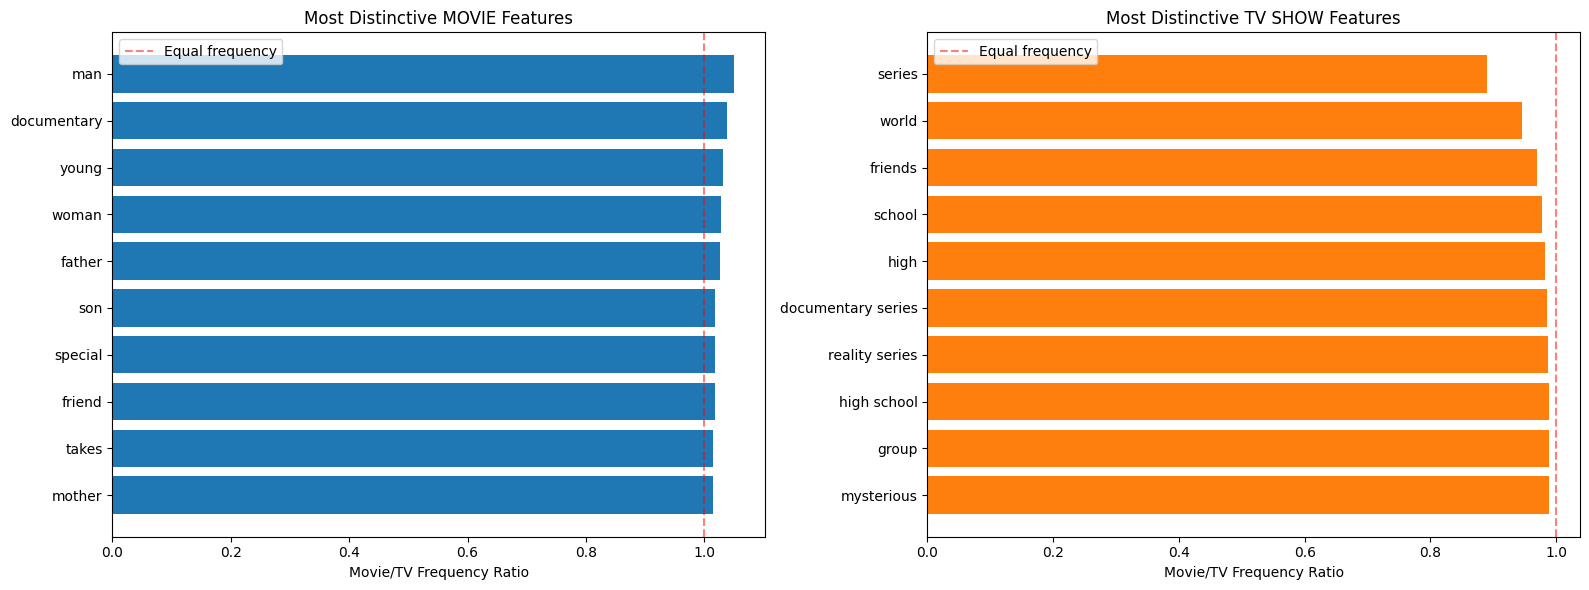

In [31]:
# Calculate relative frequency for each feature in each class
movie_filtered = combined_counts_filtered[movie_mask_filtered.values]
tv_filtered = combined_counts_filtered[tv_mask_filtered.values]

# Total counts per class
movie_totals = movie_filtered.sum(axis=0).A1
tv_totals = tv_filtered.sum(axis=0).A1

# Normalize by number of descriptions in each class
movie_freq_norm = movie_totals / movie_mask_filtered.sum()
tv_freq_norm = tv_totals / tv_mask_filtered.sum()

# Calculate ratio: how much more common in one class vs the other
# Add small constant to avoid division by zero
ratio = (movie_freq_norm + 1) / (tv_freq_norm + 1)

# Create DataFrame
distinctiveness = pd.DataFrame({
    'feature': text_feature_names,
    'movie_freq': movie_freq_norm,
    'tv_freq': tv_freq_norm,
    'ratio': ratio
})

# Sort by how distinctive they are for each class
most_movie_like = distinctiveness.nlargest(10, 'ratio')
most_tv_like = distinctiveness.nsmallest(10, 'ratio')

print("Top 10 Most Distinctive MOVIE Features:")
print(most_movie_like[['feature', 'ratio']].to_string(index=False))
print("\n" + "="*50 + "\n")
print("Top 10 Most Distinctive TV SHOW Features:")
print(most_tv_like[['feature', 'ratio']].to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movie-distinctive features
ax1.barh(range(10), most_movie_like['ratio'].values, color='#1f77b4')
ax1.set_yticks(range(10))
ax1.set_yticklabels(most_movie_like['feature'].values)
ax1.set_xlabel('Movie/TV Frequency Ratio')
ax1.set_title('Most Distinctive MOVIE Features')
ax1.axvline(1, color='red', linestyle='--', alpha=0.5, label='Equal frequency')
ax1.legend()
ax1.invert_yaxis()

# TV-distinctive features
ax2.barh(range(10), most_tv_like['ratio'].values, color='#ff7f0e')
ax2.set_yticks(range(10))
ax2.set_yticklabels(most_tv_like['feature'].values)
ax2.set_xlabel('Movie/TV Frequency Ratio')
ax2.set_title('Most Distinctive TV SHOW Features')
ax2.axvline(1, color='red', linestyle='--', alpha=0.5, label='Equal frequency')
ax2.legend()
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizers (same settings as before)
tfidf_word_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50
)

tfidf_bigram_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    max_features=50
)

# Fit and transform
tfidf_word_counts = tfidf_word_vectorizer.fit_transform(netflix_titles_filtered['description'])
tfidf_bigram_counts = tfidf_bigram_vectorizer.fit_transform(netflix_titles_filtered['description'])

print(f"TF-IDF word features shape: {tfidf_word_counts.shape}")
print(f"TF-IDF bigram features shape: {tfidf_bigram_counts.shape}")

TF-IDF word features shape: (8807, 50)
TF-IDF bigram features shape: (8807, 50)


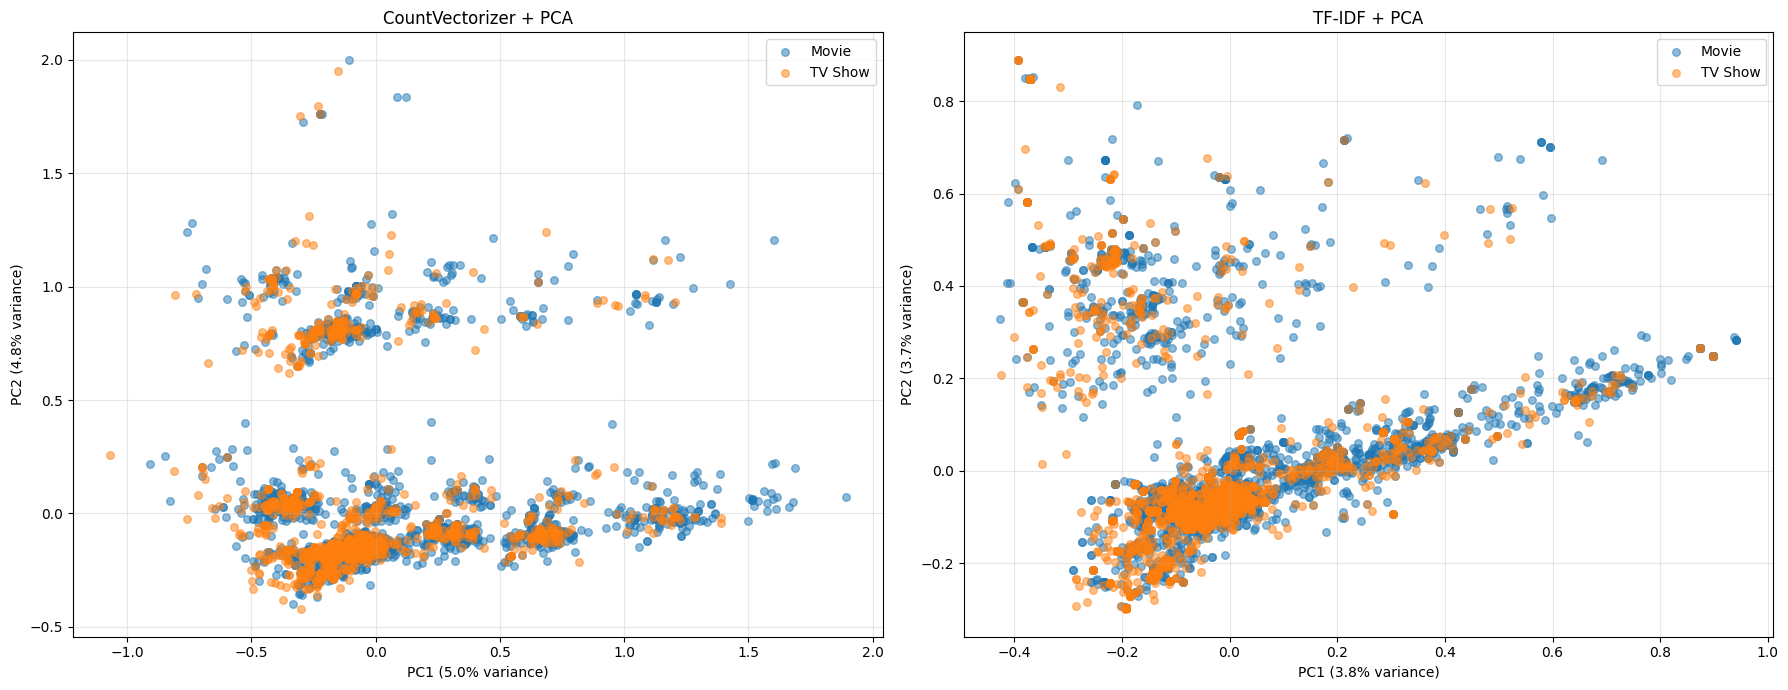


CountVectorizer - Total variance explained: 9.79%
TF-IDF - Total variance explained: 7.47%

TF-IDF often provides better separation by emphasizing distinctive words!


In [33]:
from scipy.sparse import hstack

# Combine TF-IDF features
tfidf_combined = hstack([tfidf_word_counts, tfidf_bigram_counts])

# Apply PCA
pca_tfidf = PCA(n_components=2)
tfidf_pca = pca_tfidf.fit_transform(tfidf_combined.toarray())

# Create side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# CountVectorizer PCA (left)
movie_pca_count = fitted_pca[movie_mask_filtered.values]
tv_pca_count = fitted_pca[tv_mask_filtered.values]

ax1.scatter(movie_pca_count[:, 0], movie_pca_count[:, 1], 
            alpha=0.5, c='#1f77b4', label='Movie', s=30)
ax1.scatter(tv_pca_count[:, 0], tv_pca_count[:, 1], 
            alpha=0.5, c='#ff7f0e', label='TV Show', s=30)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('CountVectorizer + PCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# TF-IDF PCA (right)
movie_pca_tfidf = tfidf_pca[movie_mask.values]
tv_pca_tfidf = tfidf_pca[tv_mask.values]

ax2.scatter(movie_pca_tfidf[:, 0], movie_pca_tfidf[:, 1], 
            alpha=0.5, c='#1f77b4', label='Movie', s=30)
ax2.scatter(tv_pca_tfidf[:, 0], tv_pca_tfidf[:, 1], 
            alpha=0.5, c='#ff7f0e', label='TV Show', s=30)
ax2.set_xlabel(f'PC1 ({pca_tfidf.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca_tfidf.explained_variance_ratio_[1]:.1%} variance)')
ax2.set_title('TF-IDF + PCA')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCountVectorizer - Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"TF-IDF - Total variance explained: {pca_tfidf.explained_variance_ratio_.sum():.2%}")
print("\nTF-IDF often provides better separation by emphasizing distinctive words!")

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE


# Get labels (Movie vs TV Show)
labels = netflix_titles_filtered['type']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    combined_counts_filtered, labels_filtered, test_size=0.2, random_state=42, stratify=labels_filtered
)

# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Train on balanced data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 59.31%

Classification Report:
              precision    recall  f1-score   support

       Movie       0.75      0.62      0.68       992
     TV Show       0.38      0.52      0.44       436

    accuracy                           0.59      1428
   macro avg       0.56      0.57      0.56      1428
weighted avg       0.64      0.59      0.61      1428



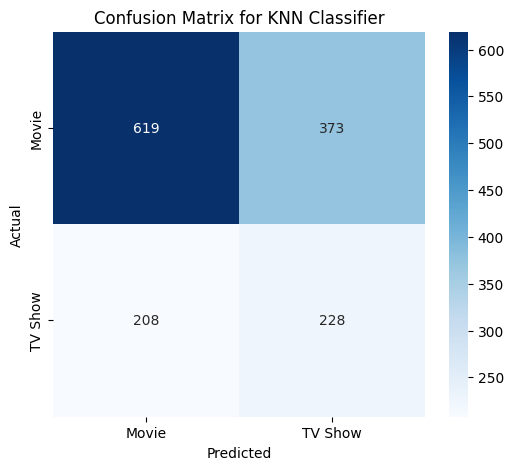

In [37]:
import seaborn as sns
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues') 
plt.title('Confusion Matrix for KNN Classifier') 
plt.show()

## 2: Audio dataset - TinySOL 🧠

Let's say we want to automatically identify instruments from a given audio file.

Watch [this video](https://www.youtube.com/watch?v=tb0gHAzpQPE). *How many instruments can you identify?* What qualities are you listening out for?

Given this task, a good choice of dataset would be TinySOL.

This dataset contains 2913 musical notes recorded from 14 different musical instruments. The instruments are:

1. Tuba 📯
2. French Horn 📯
3. Trombone 🎺
4. Trumpet 🎺
5. Accordion 🎹
6. Double bass 🎻
7. Violin 🎻
8. Viola 🎻
9. Cello 🎻
10. Bassoon 🪈
11. Clarinet 🪈
12. Flute 🪈
13. Oboe 🪈
14. Saxophone 🎷

TinySOL is released under a **CC-BY-4.0 license**. This means that it can be reused **by anyone and for any purpose** (including machine learning), on the condition that the creator is appropriately credited.

For more information on TinySOL and how it was created, [check out this website.](https://zenodo.org/records/3685331)

### MIRData 🎹

In order to work with TinySOL in Python, we're going to use the [`mirdata`](https://github.com/mir-dataset-loaders/mirdata) library. This will allow us to download the dataset and load its audio files **directly in Python**.


Now let's download TinySOL. Note that this dataset is quite large (**1 gigabyte**). Depending on the internet connection, *it may take a while to download*, so please be patient

> If you encounter any HTML errors, please **retry the download** by **rerunning the cell**

In [38]:
import mirdata 

tinysol = mirdata.initialize('tinysol')
tinysol.download()

`mirdata` also allows us to *validate* the dataset, to make sure that we have all the correct files and that nothing is corrupt.

In [39]:
tinysol.validate()

100%|██████████| 2913/2913 [01:03<00:00, 45.92it/s]


({'metadata': {}, 'tracks': {}}, {'metadata': {}, 'tracks': {}})

Great! We've downloaded TinySOL and confirmed that the dataset is valid and complete. Let's take a listen to one of the audio files, selected randomly:

In [40]:
import IPython.display as ipd

track = tinysol.choice_track()
# Identical output to `librosa.load(filename=...)`
y, sr = track.audio
ipd.Audio(y, rate=sr)

> If you run the above code again, you'll get a different file!

What instrument is it?

In [41]:
track.instrument_full

'Accordion'

Note that TinySOL was recorded with a *sample rate* of 44,100 Hz. If you're not sure what this means, check out the previous notebook.

### Dataset Exploration 📊

The first thing we should do once we decided to work with a dataset is explore it.

We can start by taking a look at **how many recordings there are** in TinySOL.

In [42]:
len(list(tinysol.load_tracks().values()))

2913

OK, we have **2913 recordings in total** to work with.

Next, let's look at **the number of recordings per instrument**.

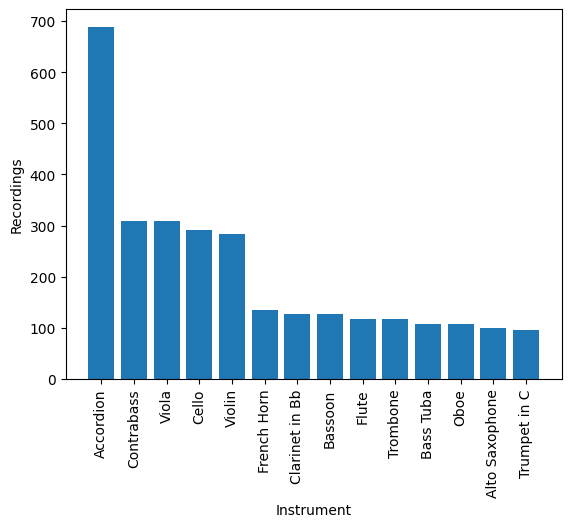

In [43]:
instrs = [rec.instrument_full for rec in tinysol.load_tracks().values()]
res = pd.Series(instrs).value_counts().reset_index(drop=False)

plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.xlabel("Instrument")
plt.ylabel("Recordings")
plt.show()

Great, from looking at this plot, we can see that **the vast majority of recordings** are on the Accordion. We have over **two times as many Accordion recordings** as we do Contrabass, *the next most common class*. We might call a dataset like this **unbalanced**.

Next, we can look at the number of recordings by each **family** of instruments.

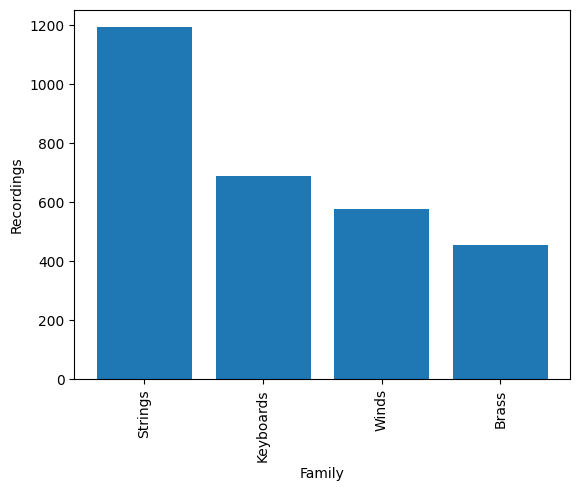

In [44]:
fams = [rec.family for rec in tinysol.load_tracks().values()]

# Note that this code is unchanged from the previous cell
res = pd.Series(fams).value_counts().reset_index(drop=False)
plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.gca().set(xlabel="Family", ylabel="Recordings")
plt.show()

Great: we can see now that the vast majority of recordings are by instruments from the **string** family (e.g., **Violin**, **Viola**), whereas **brass** recordings (e.g., **Trumpet**, **Trombone**) are much less common in our dataset.

*What other exploratory analyses could we perform for this dataset?*

Think about:
- The duration of recordings
- The qualities of these recordings (e.g., the number of notes they contain)
- Anything else?

### Visualising the Waveform and Spectrogram 🎨

As we saw before, we have two ways of visualising audio information: the waveform, which shows the signals evolution in time, and the spectrogram, that shows the energy for different frequencies of the signal and how they change in time.

Let's look at at the waveform of our file:

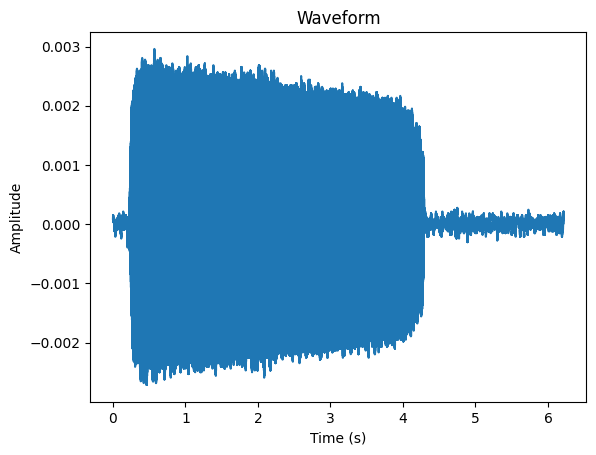

In [45]:
import numpy as np

x_seconds = np.arange(len(y)) / sr
plt.plot(x_seconds, y)
plt.gca().set(xlabel="Time (s)", ylabel="Amplitude")
plt.title("Waveform")
plt.show()

It is clear that the audio deals with only one note! For this particular track: How long does it take for it to reach the maximum amplitude? Does it reach it rapidly or does it increse gradually?

What about the spectrogram?

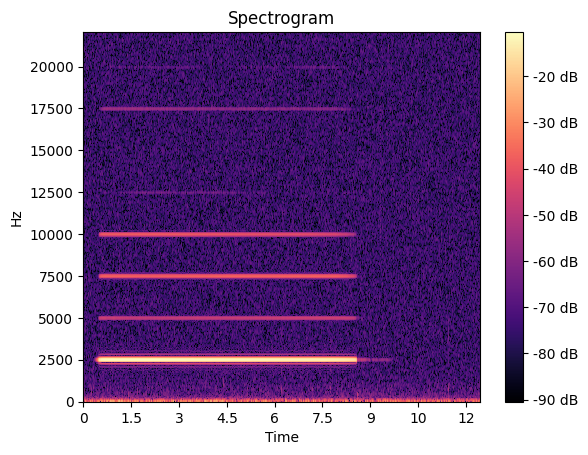

In [46]:
import librosa 

X_stft = np.abs(librosa.stft(y, win_length=512, hop_length=256))
spect = librosa.amplitude_to_db(X_stft)

librosa.display.specshow(spect, sr=sr, x_axis="time", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

What do you see? Is the energy concentrated in a certain frequency region or is it spread out? Does the distribution of energy across frequencies change over time or does it stay more or less the same?

## Feature Engineering 🔢

In the **Data Analysis** notebook, we saw how to extract some useful statistical information from an audio signal. We call these summary statistics **features**.

Now, we'll try to see how this **features** could help us understand the difference between instruments, finding values for them for all the different **samples** of the dataset.

### Feature Extraction 🏗️

In the **Data Representations** notebook, we explored two types of **temporal features**:
1. **Root Mean Square**: measures the average loudness of a sound over time: a whisper has a low RMS, while a shout has a high RMS
2. **Zero-Crossing Rate**: the fraction of samples in a frame that cross 0, usually higher for noisy or percussive sounds

We also explored two **spectrotemporal features**:

3. **spectral centroid**: the average frequency of every **column** in the spectrogram
4. **spectral bandwidth**: the standard deviation of every **column** in the spectrogram


We're going to define a Python **function** that does the following:

1. Calculates the spectrogram corresponding to an audio file
2. Extracts the **six features** described above from every frame of the spectrogram
3. Gathers these features into a matrix with shape `(N_frames, N_features)`. In other words, every **row** is a frame, and every **column** is a feature.

In [47]:
def extract_features(waveform: np.ndarray, sr: float) -> np.ndarray:
    """
    Extracts features from an audio signal.

    Returns a 2D array, where each row is a frame and each column is a feature
    """
    # Compute the spectrogram
    X_stft = librosa.stft(waveform, win_length=512, hop_length=256)
    spect = np.abs(librosa.amplitude_to_db(np.abs(X_stft)))

    # Extract every feature
    spectral_centroids = librosa.feature.spectral_centroid(S=spect,)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(S=spect,)
    rmse = librosa.feature.rms(S=spect,)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(waveform, frame_length=512, hop_length=256)

    # Stack the features to the shape (N_frames, N_features)
    return np.vstack([
        spectral_centroids,
        spectral_bandwidth,
        rmse,
        zero_crossing_rate,
    ]).T


features = extract_features(y, sr)


Let's check the shape of the feature matrix:

In [48]:
print(features.shape)

(1072, 4)


Great! We can see the number of frames in order file as the first number in the tuple above. For every frame, we've extracted 4 **spectral features**.


#### Frames or Recordings? 🖼

While we could train our model on data extracted from every **frame**, there might be some problems with this:

- Given that each frame lasts a very short amount of time (around 0.01 second!), we might expect successive frames to contain **very similar information**;
- Some frames might not contain audio: for example, if the musician stopped playing **before the recording ended**. These frames could confuse a model.

Because of these reasons, we can instead **average** every feature for a single recording. Recall the equation for the mean of the values in a vector $x$:

$$
\text{mean}(x) = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

To calculate this, we can simply use `numpy`:

In [49]:
features_vector = np.mean(features, axis=0)
print(features_vector.shape)

(4,)


> **Good to know:** notice how we set the `axis=0` parameter above. This means that we **averaged over** the first axis in the matrix (i.e., frames). Compare the shape of `extracted` and `extracted_vector` to see what we mean.
>
> ***What would happen if we set `axis=1`? What shape would we get?***

We now have a **feature vector**: a one-dimensional vector with shape `(N_features,)`. Let's print this out:

In [50]:
print(features_vector.round(3))

[5.629015e+03 3.152885e+03 1.630000e+00 9.500000e-02]


### Extract the features for our whole Database.

For each of the sample audios of the database we need to:

1. Load the audio file from TinySOL
2. Extract the six spectral features from every frame to create a matrix with shape `(N_frames, N_features)`
3. Average every feature over each frame to create a vector of shape `(N_features,)`

We can do that in a function, let's call it `get_averaged_features`

In [51]:
def get_averaged_features(track: tuple) -> np.ndarray:
    """
    Extract average features for a single recording.
    """
    # Extract the features for every frame: shape (N_frames, N_features)
    features = extract_features(track.audio[0], track.audio[1])
    # Average the features over all frames to create a vector: shape (N_features,)
    averaged_features = np.mean(features, axis=0)
    return averaged_features

But, how should we organise the storage of this information once we compute it?

We can stack this vector for every recording to create a matrix with shape `(N_recordings, N_features)`

Run the cell below to extract features from all the recordings in `tinysol`. Note that this may take a while, *so please be patient!*

In [52]:
# Load up all the recordings from tinysol
all_recordings = tinysol.load_tracks()
print(f"Number of recordings: {len(all_recordings)}")

Number of recordings: 2913


In [53]:
from joblib import Parallel, delayed

# Initialise an empty list to store all the feature vectors
all_features = []

# We would normally run the following code:

# for track in filtered_recordings.values():
#     all_features.append(get_averaged_features(track))

# The problem is that it is too slow! We're going to speed it up, but don't worry about the details,
# just know that this allows us to run several pieces of code at the same time (in parallel)

with Parallel(n_jobs=-1, verbose=5) as parallel:
    all_features = parallel(delayed(get_averaged_features)(track) for track in all_recordings.values())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:   43.4s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   52.7s
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1136 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2162 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 2576 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 2913 out of 2913 | elapsed:  4.0min finished


In [54]:
# Stack all of the vectors into a matrix with shape (N_recordings, N_features)
feature_matrix = np.array(all_features)

Great! We can confirm that our pipeline worked correctly by looking at the *shape of the feature matrix*:

In [55]:
print(feature_matrix.shape)

(2913, 4)


This shows we have 2913 recordings, the same number as in TinySOL. For each of these recordings, we have 4 features.

### Visualising Features 📃

Let's start taking a closer look at some of our features.

For now, we'll just visualise the spectral centroid and zero-crossing rate of each recording using **histograms**. These plots show the distribution of values by binning data into discrete groups.

We'll use the `seaborn` library to create these plots.

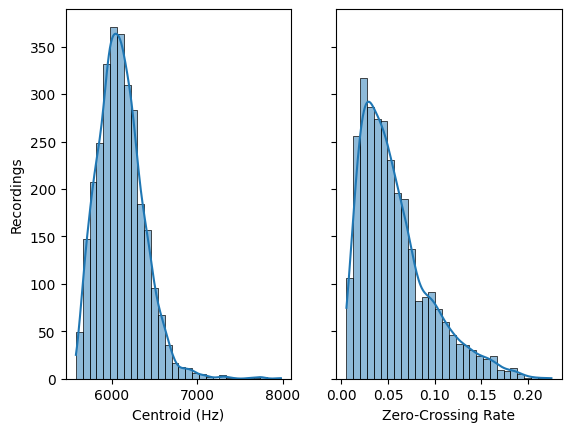

In [56]:
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)

sns.histplot(feature_matrix[:, 0], kde='True', ax=ax[0], bins=30)
sns.histplot(feature_matrix[:, 3], kde='True', ax=ax[1], bins=30)

ax[0].set(xlabel="Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.show()

Now, this is for all the recordings group together. What would happen if we were to get one histogram per instrument family?

In [57]:
feature_names = ['Spectral Centroid', 'Spectral Bandwidth',
                 'RMS', 'Zero-Crossing Rate']
df_features = pd.DataFrame(feature_matrix, columns=feature_names)
# Get the family labels for coloring
families = [rec.family for rec in all_recordings.values()]
df_features['Family'] = families

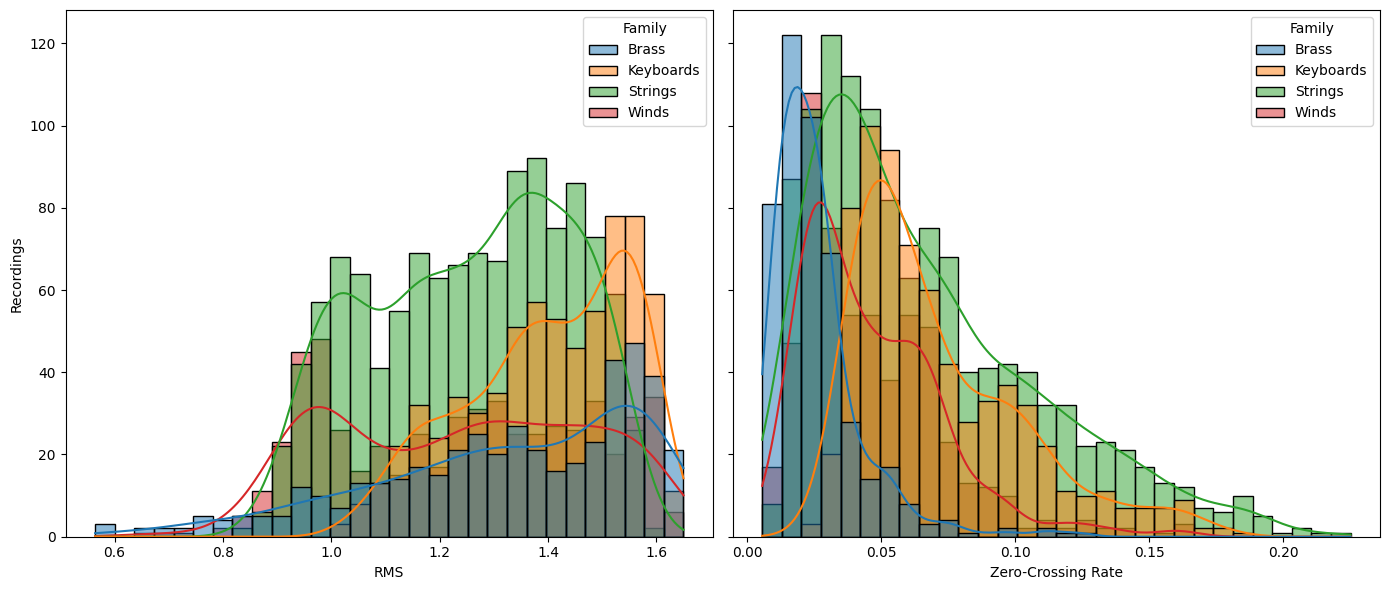

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='RMS', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Zero-Crossing Rate', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="RMS", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.tight_layout()
plt.show()

We can see different behaviour for different families! This gives us a glue that this features could be useful for analysing a recording and automatically indicate which family it belongs to. What about the other two features?

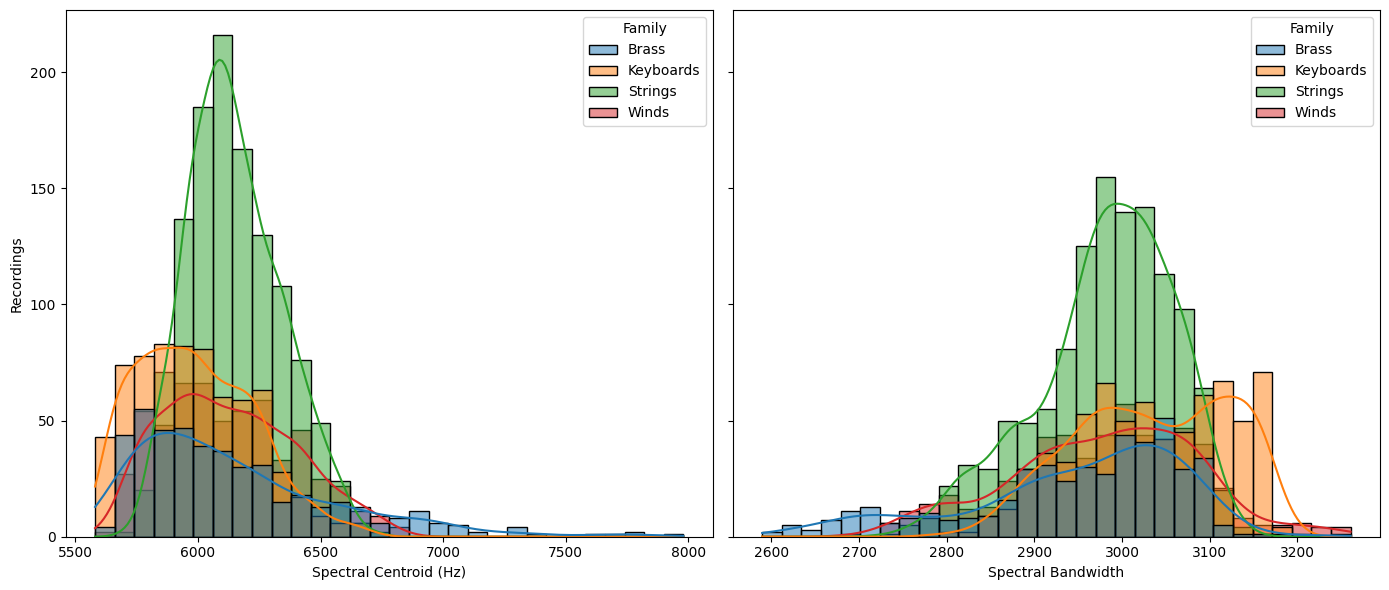

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='Spectral Centroid', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Spectral Bandwidth', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="Spectral Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Spectral Bandwidth", ylabel="")

plt.tight_layout()
plt.show()

Looking at all the graphs, can you see any feature better than the others at separating between families?

We will use all of this information for training a classifier in the next notebook.

In [60]:
df_features

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate,Family
0,5633.172265,3118.915778,1.649794,0.008589,Brass
1,5643.018662,3119.580742,1.627017,0.008592,Brass
2,5685.157258,3094.128050,1.610967,0.011369,Brass
3,5646.330359,3118.488256,1.627235,0.019568,Brass
4,5689.932701,3087.401249,1.633211,0.012646,Brass
...,...,...,...,...,...
2908,5992.137261,3092.541037,0.939491,0.126032,Winds
2909,6027.031350,3082.283561,1.122661,0.165413,Winds
2910,6037.915892,3090.484844,1.058522,0.160057,Winds
2911,5914.399967,3110.747552,0.997949,0.080559,Winds


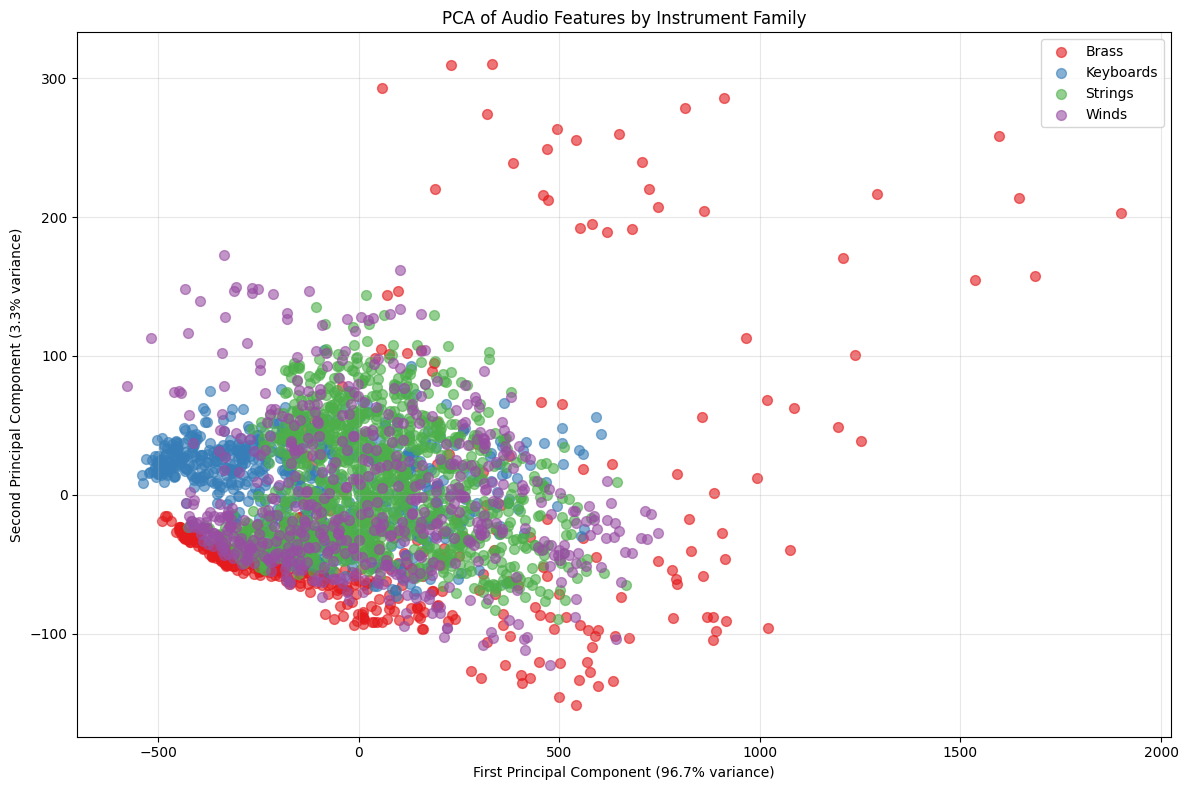

Variance explained by each component: [0.96659815 0.03340161]
Total variance explained: 100.00%


In [61]:
from sklearn.decomposition import PCA

# Perform PCA on the audio features
pca_audio = PCA(n_components=2)
features_pca = pca_audio.fit_transform(df_features[feature_names])

# Create a scatter plot
plt.figure(figsize=(12, 8))

# Get unique families and colors
families_unique = df_features['Family'].unique()
colors = plt.cm.Set1(range(len(families_unique)))

# Plot each family with a different color
for family, color in zip(families_unique, colors):
    mask = df_features['Family'] == family
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                label=family, alpha=0.6, s=50, color=color)

plt.xlabel(f'First Principal Component ({pca_audio.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca_audio.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Audio Features by Instrument Family')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance explained by each component: {pca_audio.explained_variance_ratio_}")
print(f"Total variance explained: {pca_audio.explained_variance_ratio_.sum():.2%}")

PCA Loadings (how much each feature contributes to each component):
                         PC1       PC2
Spectral Centroid   0.953546  0.301247
Spectral Bandwidth -0.301248  0.953545
RMS                -0.000499 -0.001242
Zero-Crossing Rate -0.000013  0.000437

Interpretation:
- Larger absolute values mean that feature is more important for that PC
- Positive values increase the PC value, negative values decrease it


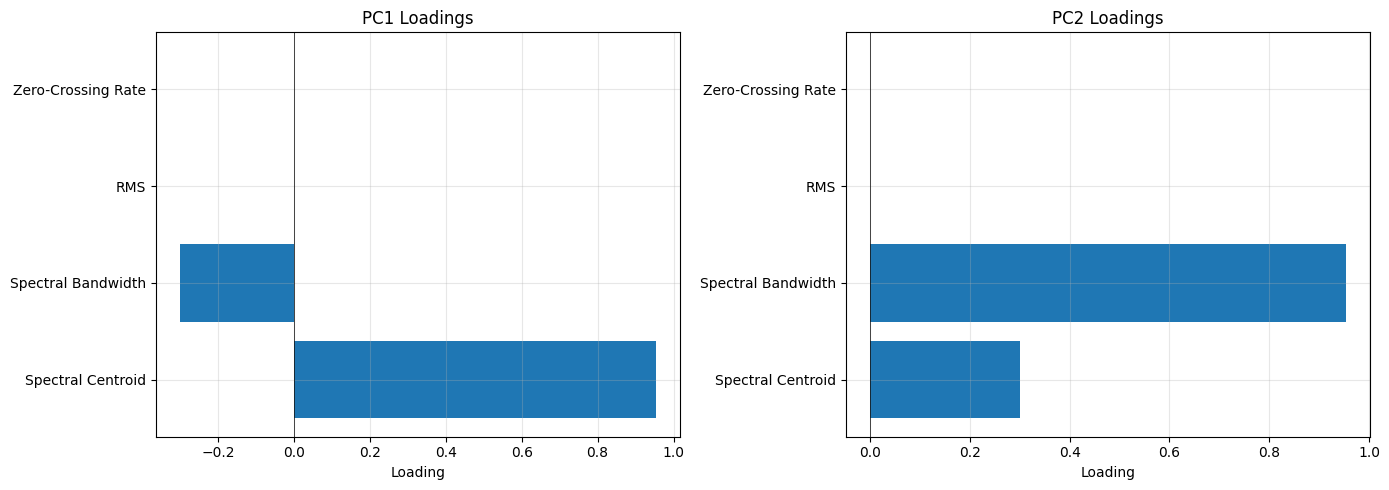

In [62]:
# Display the loadings (components)
loadings = pd.DataFrame(
    pca_audio.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("PCA Loadings (how much each feature contributes to each component):")
print(loadings)
print("\nInterpretation:")
print("- Larger absolute values mean that feature is more important for that PC")
print("- Positive values increase the PC value, negative values decrease it")

# Visualize the loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, pc in enumerate(['PC1', 'PC2']):
    axes[i].barh(feature_names, loadings[pc])
    axes[i].set_xlabel('Loading')
    axes[i].set_title(f'{pc} Loadings')
    axes[i].axvline(0, color='black', linewidth=0.5)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Images : CIFAR-10

Now it's the time for images!

We will analyse the images from the [CIFAR-10 dataset](https://www.kaggle.com/competitions/cifar-10/data), consisting on 32x32 color images, belonging to one of these classes:
* airplane 
* automobile 
* bird 
* cat 
* deer 
* dog 
* frog 
* horse 
* ship 
* truck

First, let's download the dataset from `kaggle`:

In [63]:
# Download the CIFAR-10 dataset from Kaggle
!kaggle datasets download -d oxcdcd/cifar10

Dataset URL: https://www.kaggle.com/datasets/oxcdcd/cifar10
License(s): copyright-authors
cifar10.zip: Skipping, found more recently modified local copy (use --force to force download)


Let's extract it. We'll have a `labels.txt` file that indicates the name of the classes, and  `test` and `train` folders with images for the different classes. Don't worry about this distinction now, we will get to it in the next notebook!

In [64]:
with zipfile.ZipFile("cifar10.zip", 'r') as zip_ref:
    zip_ref.extractall("cifar10")

Let's look at some images we have for automobiles:

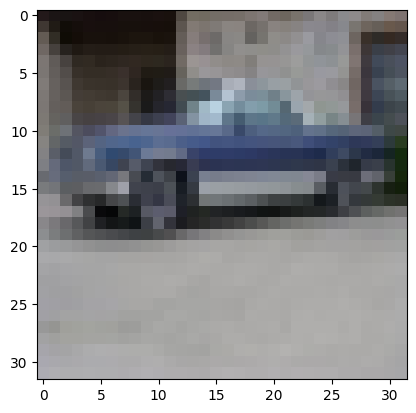

In [65]:
import skimage
import os

# change the label as you wish to explore the other classes!
label = 'automobile'
images_base_path = f'cifar10/cifar10/train/{label}/'
images_paths = os.listdir(images_base_path)

# change the index here to show a different image
index = 0
image_to_show = images_paths[index]
image = skimage.io.imread(os.path.join(images_base_path, image_to_show))
plt.imshow(image)

> Change the label and the index values in the code above to explore the dataset!

This dataset has been used heavily for classification tasks, that is, developing a system that given a new image that belongs to one of the defined classes, can confidently identify which class it belongs to.

For the sake of simplicity, we will now work with only two classes: `automobiles` and `airplanes`.

We can first analyse the colour histogram of the image we checked before.

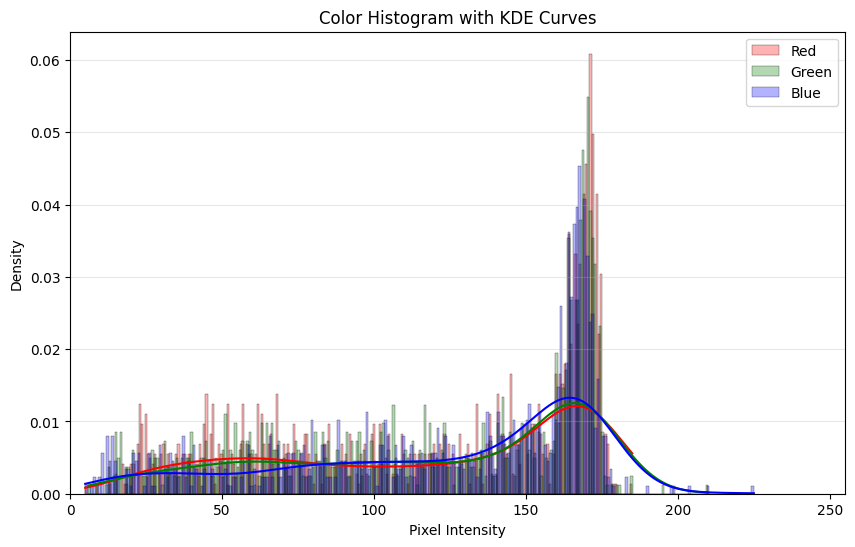

In [66]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Extract each color channel
red = image[:, :, 0].flatten()
green = image[:, :, 1].flatten()
blue = image[:, :, 2].flatten()

# Plot histograms with KDE curves using seaborn
sns.histplot(red, bins=255, color='red', alpha=0.3, kde=True, label='Red', stat='density')
sns.histplot(green, bins=255, color='green', alpha=0.3, kde=True, label='Green', stat='density')
sns.histplot(blue, bins=255, color='blue', alpha=0.3, kde=True, label='Blue', stat='density')

plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.title('Color Histogram with KDE Curves')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 255)
plt.show()

Can we extend the code to average the histogram of the whole class?

In [72]:
def plot_histogram_for_class(label):
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)

    plt.figure(figsize=(10, 6))

    # Initialize lists to accumulate all pixel values
    all_red = []
    all_green = []
    all_blue = []

    for image_name in images_paths[:5]:
        image = skimage.io.imread(os.path.join(images_base_path, image_name))
        # Extract each color channel
        all_red.extend(image[:, :, 0].flatten())
        all_green.extend(image[:, :, 1].flatten())
        all_blue.extend(image[:, :, 2].flatten())

    # Plot histograms with KDE curves using seaborn
    sns.histplot(all_red, bins=255, color='red', alpha=0.3, kde=True, label='Red', stat='density')
    sns.histplot(all_green, bins=255, color='green', alpha=0.3, kde=True, label='Green', stat='density')
    sns.histplot(all_blue, bins=255, color='blue', alpha=0.3, kde=True, label='Blue', stat='density')

    plt.xlabel('Pixel Intensity')
    plt.ylabel('Density')
    plt.title(f'Color Histogram with KDE Curves - {label.title()}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

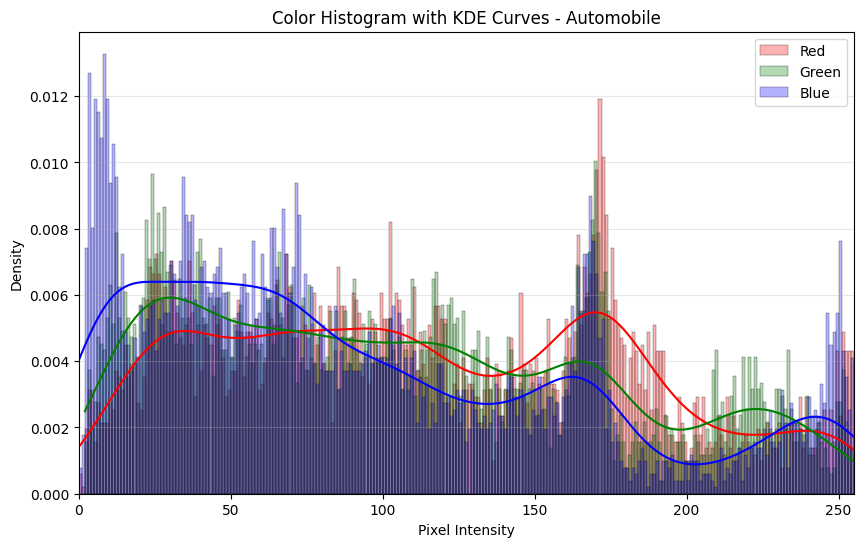

In [73]:
plot_histogram_for_class('automobile')

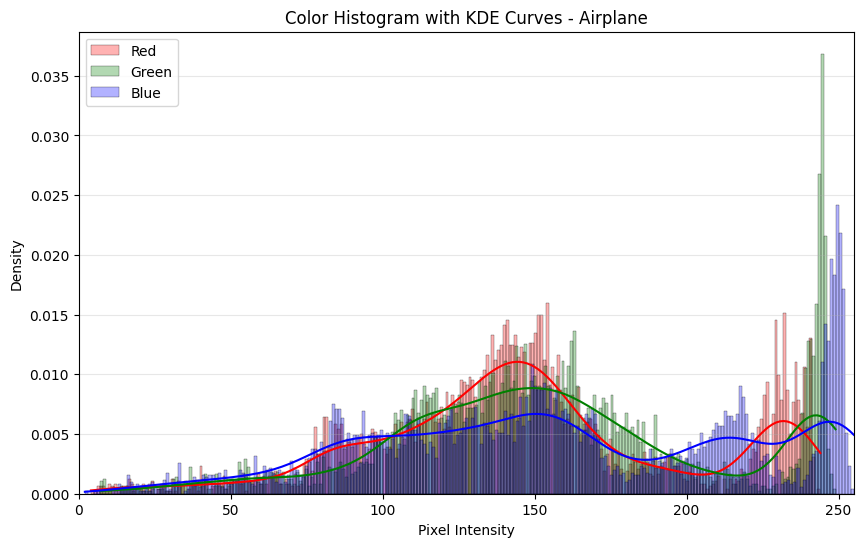

In [74]:
plot_histogram_for_class('airplane')

We can see that the colour histograms for the two classes are completely diferent! If we have a new image of an airplane or an automobile and we compute its colour histogram, as a first approach we could check which one of these two is more similar, and therefore conclude what is the image most likely is.

To summarise that information in numbers, we can calculate the mean and standard deviation of each channel of each image:

In [70]:
def extract_color_stats(image):
    """
    Extract mean and standard deviation for each color channel (RGB).
    
    Returns a vector with 6 features: [mean_R, mean_G, mean_B, std_R, std_G, std_B]
    """
    red = image[:, :, 0].flatten()
    green = image[:, :, 1].flatten()
    blue = image[:, :, 2].flatten()
    
    stats = [
        np.mean(red), np.mean(green), np.mean(blue),
        np.std(red), np.std(green), np.std(blue)
    ]
    
    return np.array(stats)

# Test on the current image
color_stats = extract_color_stats(image)
print("Color statistics (mean_R, mean_G, mean_B, std_R, std_G, std_B):")
print(color_stats.round(2))

Color statistics (mean_R, mean_G, mean_B, std_R, std_G, std_B):
[118.18 119.5  122.87  51.52  50.72  49.87]


We could then calculate those values for all the images in our dataset, and be ready for training in the next notebook.

In [82]:
images_stats = np.zeros((0, 6))  # Initialize an empty array to store stats for all images
labels = []

for label in ['automobile', 'airplane']:
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)
    for image in images_paths:
        img = skimage.io.imread(os.path.join(images_base_path, image))
        stats = extract_color_stats(img)
        images_stats = np.vstack([images_stats, stats])  # Append the stats to the array
        labels.append(label)

What does our table of features look like?

In [83]:
df_images = pd.DataFrame(images_stats, columns=['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B'])
df_images['label'] = labels
df_images.head()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,label
0,118.180664,119.496094,122.874023,51.516244,50.720030,49.866646,automobile
1,153.441406,141.306641,125.672852,61.136538,64.113088,65.829187,automobile
2,86.692383,41.961914,20.034180,69.927963,33.743627,19.912891,automobile
3,107.335938,97.231445,70.627930,69.433453,64.765579,38.634369,automobile
4,109.796875,129.926758,125.689453,61.164032,71.888990,88.644751,automobile


We can work with that, but he haven't used the edges information yet.

Instead of calculating edges manually, we'll use `skimage` `Canny` implementation.

In [143]:
from skimage.feature import canny

def extract_edges_stats(image):
    """
    Extract edge features using Canny edge detection.
    
    Returns statistics about the edges: [num_edges, edge_density, edge_mean, edge_std]
    """
    # Convert to grayscale if RGB
    if len(image.shape) == 3:
        gray = np.mean(image, axis=2)
    else:
        gray = image
    
    # Apply Canny edge detection
    edges = canny(gray, sigma=1.0)
    
    # Calculate edge statistics
    num_edges = np.sum(edges)
    edge_density = num_edges / edges.size

    # Divide image into 4x4 grid and calculate edge density for each region
    h, w = edges.shape
    grid_h, grid_w = h // 4, w // 4
    edge_densities = []
    for i in range(4):
        for j in range(4):
            region = edges[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
            region_density = np.sum(region) / region.size
            edge_densities.extend([region_density])
    
    return np.array([num_edges, edge_density] + edge_densities)


images_stats = np.zeros((0, 24))  # Initialize an empty array to store stats for all images
labels = []

for label in ['automobile', 'airplane']:
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)
    for image in images_paths:
        img = skimage.io.imread(os.path.join(images_base_path, image))
        stats = extract_color_stats(img)
        edges_stats = extract_edges_stats(img)
        combined_stats = np.concatenate([stats, edges_stats])
        images_stats = np.vstack([images_stats, combined_stats])  # Append the stats to the array
        labels.append(label)

In [144]:
feature_names_edge_density = [f'edge_density_{i}' for i in range(16)]
feature_names = [
    'mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B',
    'num_edges', 'edge_density'
] + feature_names_edge_density

In [146]:
images_features = pd.DataFrame(images_stats, columns=feature_names).head()

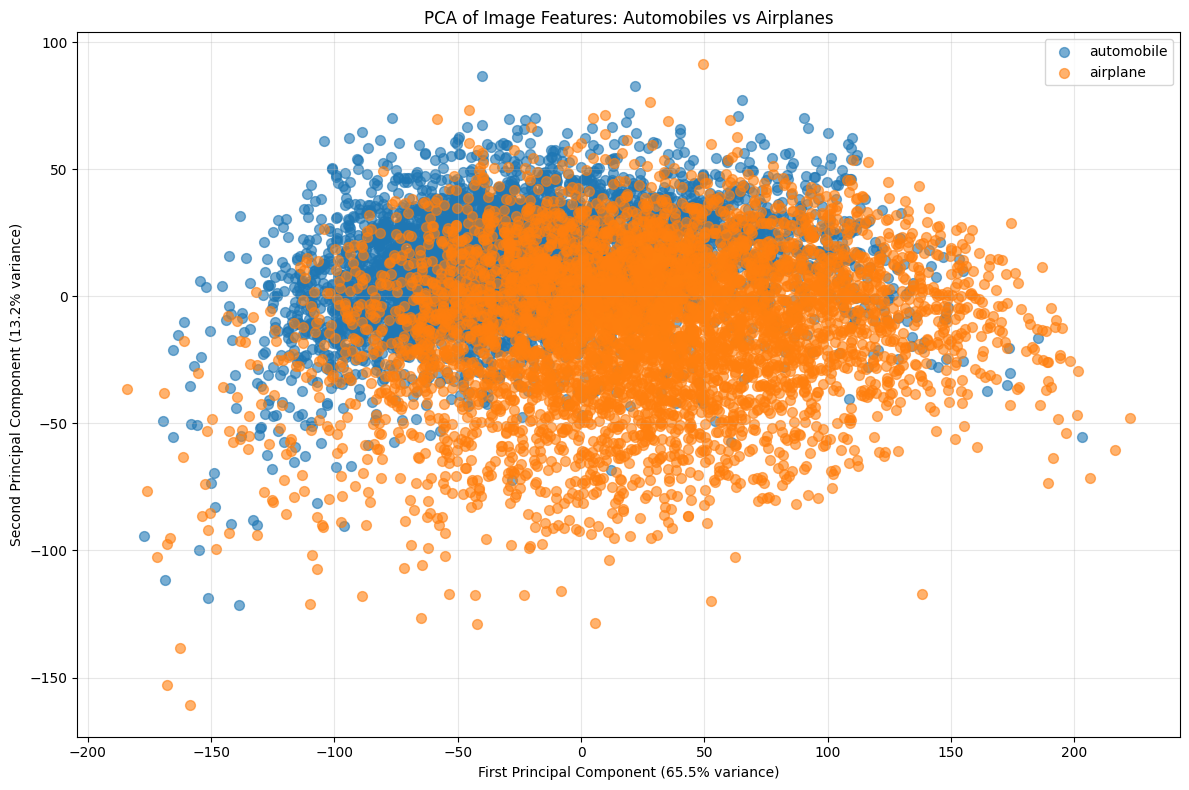

Variance explained by each component: [6.55029918e-01 1.31855716e-01 1.21026529e-01 6.62010629e-02
 1.24690344e-02 1.09993382e-02 2.40895438e-03 1.32112032e-06]
Total variance explained: 100.00%


In [149]:
from sklearn.decomposition import PCA

# Perform PCA on the image features (excluding the label column)
pca_images = PCA(n_components=8)
images_pca = pca_images.fit_transform(images_stats)

# Create a scatter plot
plt.figure(figsize=(12, 8))

# Plot each class with a different color
for label in ['automobile', 'airplane']:
    mask = np.array(labels) == label
    plt.scatter(images_pca[mask, 0], images_pca[mask, 1], 
                label=label, alpha=0.6, s=50)

plt.xlabel(f'First Principal Component ({pca_images.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca_images.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Image Features: Automobiles vs Airplanes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance explained by each component: {pca_images.explained_variance_ratio_}")
print(f"Total variance explained: {pca_images.explained_variance_ratio_.sum():.2%}")

Top 10 image features contributing to PC1:
mean_B            0.630534
mean_G            0.565656
mean_R            0.488370
std_B             0.030022
std_G             0.019459
edge_density_7   -0.000273
edge_density_2   -0.000289
edge_density_1   -0.000296
std_R            -0.002293
num_edges        -0.206566
Name: PC1, dtype: float64


Top 10 image features contributing to PC2:
num_edges          0.765010
mean_R             0.468614
std_G              0.215021
std_R              0.209893
std_B              0.176721
mean_G             0.126472
edge_density_1     0.000943
edge_density_2     0.000939
edge_density_13    0.000913
mean_B            -0.240078
Name: PC2, dtype: float64


Top 10 image features contributing to PC3:
num_edges         0.538734
mean_B            0.287098
mean_G            0.069599
edge_density_3    0.000739
edge_density_1    0.000723
edge_density_0    0.000698
mean_R           -0.180837
std_B            -0.425704
std_R            -0.440058
std_G            -0.46

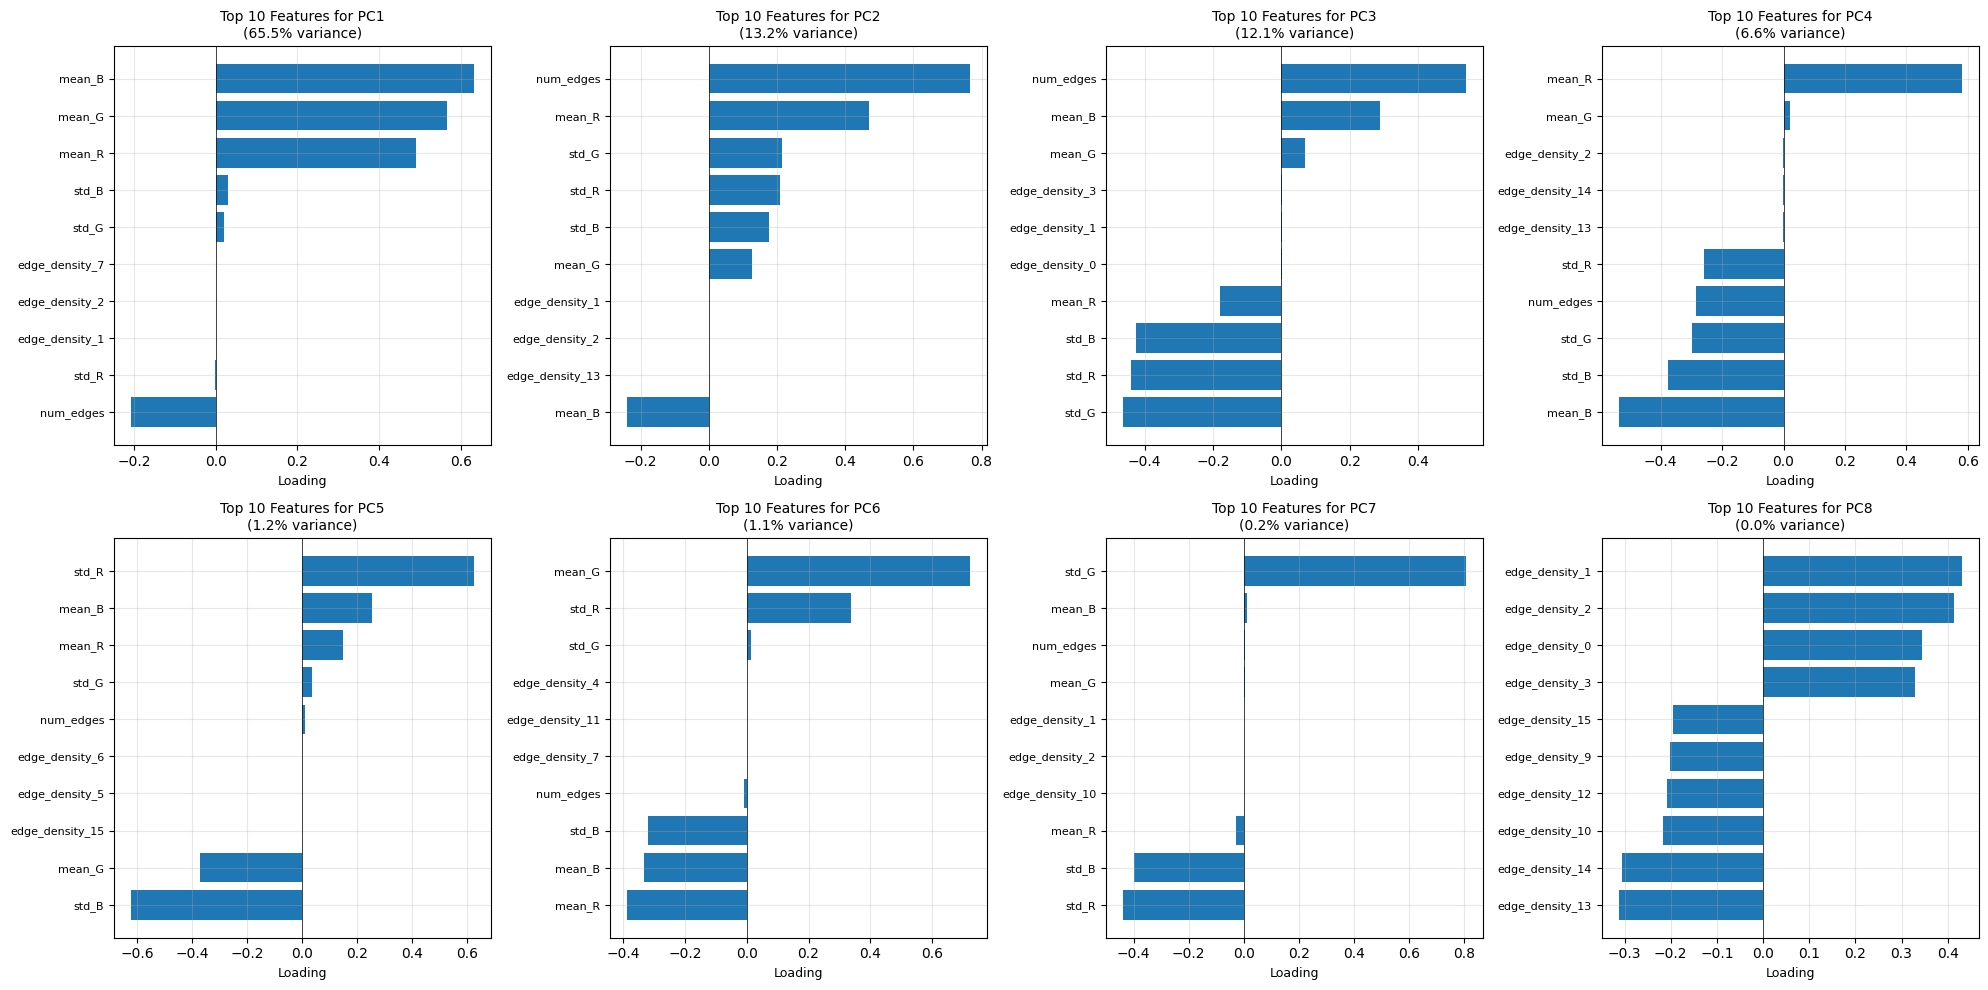

In [153]:
# Display the loadings (components) for images
loadings_images = pd.DataFrame(
    pca_images.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'],
    index=feature_names
)

# Get top 10 features for each PC by absolute loading value and print them
for i in range(1, 9):
    pc_name = f'PC{i}'
    top_features = loadings_images[pc_name].abs().nlargest(10)
    print(f"Top 10 image features contributing to {pc_name}:")
    print(loadings_images.loc[top_features.index, pc_name].sort_values(ascending=False))
    print("\n" + "="*60 + "\n")

# Visualize the top loadings for all 8 PCs
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(8):
    pc_name = f'PC{i+1}'
    top_features = loadings_images[pc_name].abs().nlargest(10)
    pc_data = loadings_images.loc[top_features.index, pc_name].sort_values()
    
    axes[i].barh(range(len(pc_data)), pc_data.values)
    axes[i].set_yticks(range(len(pc_data)))
    axes[i].set_yticklabels(pc_data.index, fontsize=8)
    axes[i].set_xlabel('Loading', fontsize=9)
    axes[i].set_title(f'Top 10 Features for {pc_name}\n({pca_images.explained_variance_ratio_[i]:.1%} variance)', fontsize=10)
    axes[i].axvline(0, color='black', linewidth=0.5)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [154]:
# KNN classifier for image features
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    images_stats, labels, test_size=0.2, random_state=42, stratify=labels
)

knn_img = KNeighborsClassifier(n_neighbors=5)
knn_img.fit(X_train_img, y_train_img)

y_pred_img = knn_img.predict(X_test_img)

print(f"Accuracy: {accuracy_score(y_test_img, y_pred_img):.2%}")
print("\nClassification Report:")
print(classification_report(y_test_img, y_pred_img))

Accuracy: 79.70%

Classification Report:
              precision    recall  f1-score   support

    airplane       0.83      0.75      0.79      1000
  automobile       0.77      0.84      0.81      1000

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"])
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for KNN Classifier")
plt.show()

# Conclusion: Datasets
